<a href="https://www.kaggle.com/code/sonawanelalitsunil/bi-intro-to-data-cleaning-eda-and-ml-72-50?scriptVersionId=260961858" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt 
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/intro-to-data-cleaning-eda-and-machine-learning/intro-to-data-cleaning-eda-and-machine-learning.html
/kaggle/input/intro-to-data-cleaning-eda-and-machine-learning/bi.csv


## Title:
🔍 Intro to Data Cleaning, EDA, and Machine Learning in BI

## Description:
Business Intelligence (BI) thrives on clean, structured, and insightful data. This session introduces the essential steps of preparing data for analysis, starting with data cleaning to handle missing values, duplicates, and inconsistencies. We then move to Exploratory Data Analysis (EDA), where visualization and statistical techniques uncover trends, anomalies, and relationships within datasets. Finally, we explore the role of Machine Learning (ML) in BI, showing how predictive models can transform raw data into actionable insights for decision-making. By connecting data preparation, analysis, and advanced modeling, this foundation empowers BI professionals to drive smarter, data-driven strategies.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/intro-to-data-cleaning-eda-and-machine-learning/bi.csv", encoding="latin1")

In [3]:
df.head()

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
0,Christina,Binger,44,Female,Norway,Private,72,Masters,158,59.0,55
1,Alex,Walekhwa,60,M,Kenya,Private,79,Diploma,150,60.0,75
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,HighSchool,130,74.0,50
3,Shoni,Hlongwane,22,F,Rsa,Sognsvann,40,High School,120,NaN,44
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,122,91.0,80


In [4]:
df.tail()

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
72,Clara,Bernard,43,Female,France,Private,80,Bachelors,150,75.0,43
73,Julian,Nielsen,31,Male,Denmark,Sognsvann,90,Masters,158,84.0,83
74,Sophie,Brown,33,Female,UK,Sognsvann,96,Masters,158,85.0,90
75,Leon,Bauer,35,Male,Germany,Sognsvann,90,Masters,160,87.0,74
76,Mohammed,Salim,31,Male,Somali,Sognsvann,35,Masters,144,72.0,90


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fNAME          77 non-null     object 
 1   lNAME          77 non-null     object 
 2   Age            77 non-null     int64  
 3   gender         77 non-null     object 
 4   country        77 non-null     object 
 5   residence      77 non-null     object 
 6   entryEXAM      77 non-null     int64  
 7   prevEducation  77 non-null     object 
 8   studyHOURS     77 non-null     int64  
 9   Python         75 non-null     float64
 10  DB             77 non-null     int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 6.7+ KB


In [6]:
df.describe()

,Age,entryEXAM,studyHOURS,Python,DB
count,77.000000,77.000000,77.000000,75.000000,77.000000
mean,35.207792,76.753247,149.714286,75.853333,69.467532
std,10.341966,16.475784,12.743272,15.410328,17.033701
min,21.000000,28.000000,114.000000,15.000000,30.000000
25%,27.000000,69.000000,144.000000,71.000000,56.000000
50%,33.000000,80.000000,156.000000,81.000000,71.000000
75%,42.000000,90.000000,158.000000,85.000000,83.000000
max,71.000000,98.000000,160.000000,91.000000,100.000000


In [7]:
df.dtypes

fNAME             object
lNAME             object
Age                int64
gender            object
country           object
residence         object
entryEXAM          int64
prevEducation     object
studyHOURS         int64
Python           float64
DB                 int64
dtype: object

In [8]:
df.shape

(77, 11)

In [9]:
df.isnull().sum()

fNAME            0
lNAME            0
Age              0
gender           0
country          0
residence        0
entryEXAM        0
prevEducation    0
studyHOURS       0
Python           2
DB               0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['fNAME', 'lNAME', 'Age', 'gender', 'country', 'residence', 'entryEXAM',
       'prevEducation', 'studyHOURS', 'Python', 'DB'],
      dtype='object')

## Data visualizations

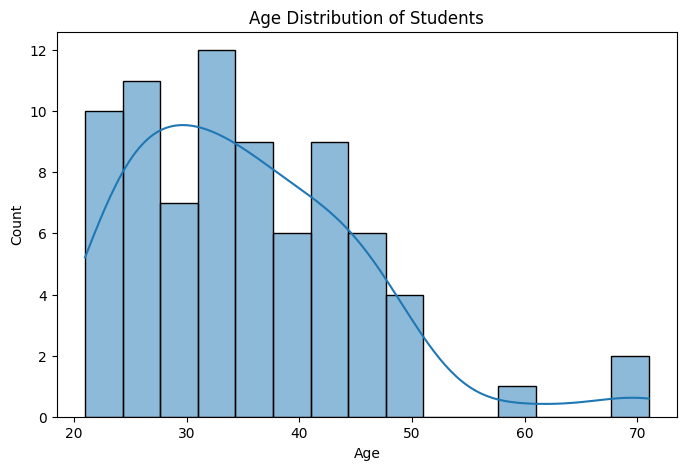

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True)
plt.title("Age Distribution of Students")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

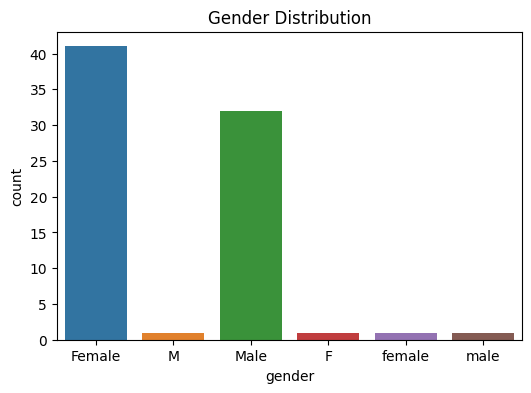

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

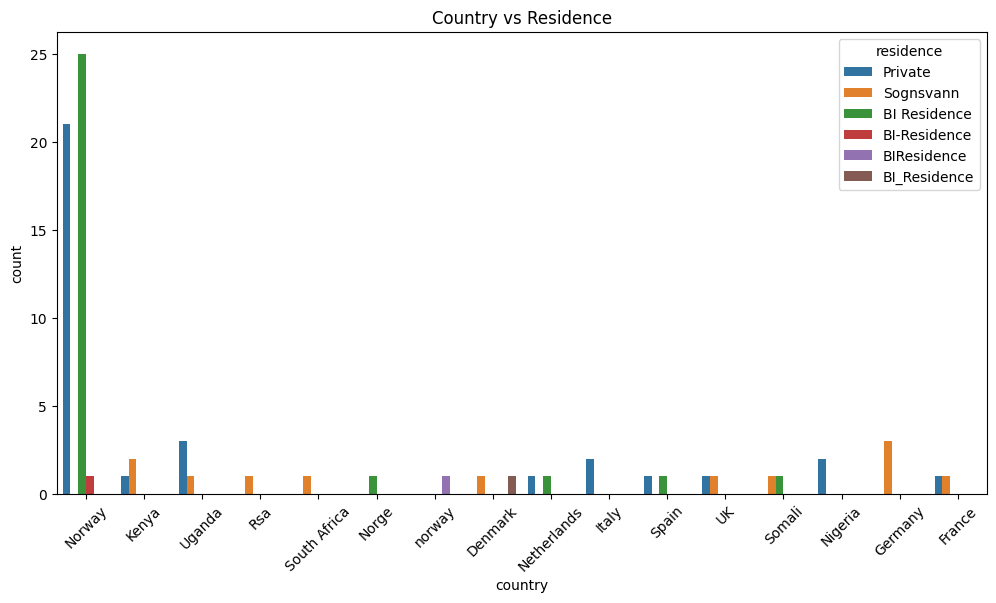

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(x="country", hue="residence", data=df)
plt.title("Country vs Residence")
plt.xticks(rotation=45)
plt.show()

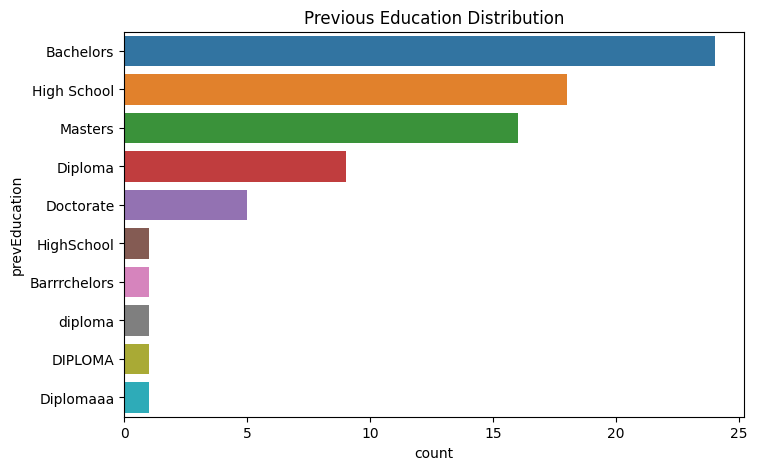

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(y="prevEducation", data=df, order=df['prevEducation'].value_counts().index)
plt.title("Previous Education Distribution")
plt.show()

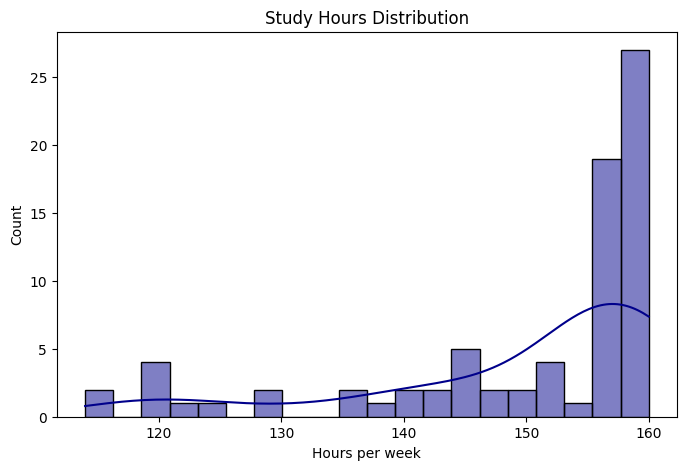

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['studyHOURS'], bins=20, kde=True, color="darkblue")
plt.title("Study Hours Distribution")
plt.xlabel("Hours per week")
plt.ylabel("Count")
plt.show()

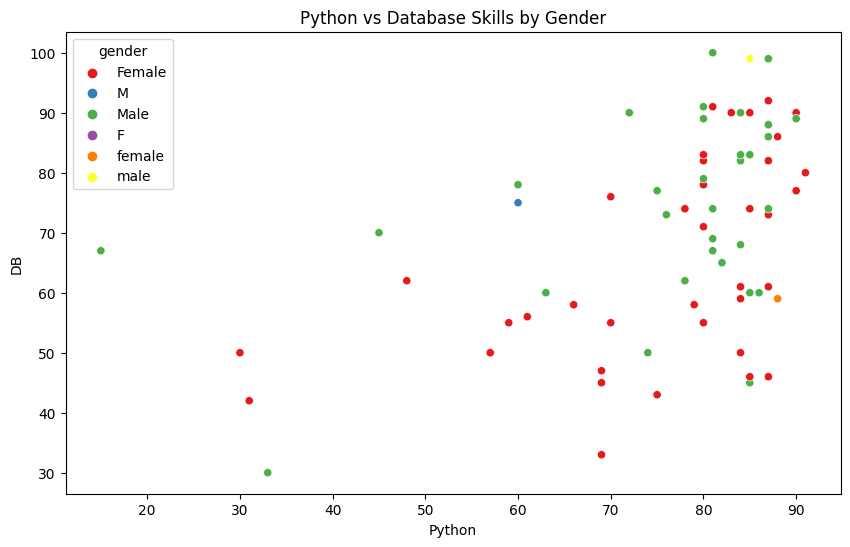

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Python", y="DB", hue="gender", data=df, palette="Set1")
plt.title("Python vs Database Skills by Gender")
plt.show()


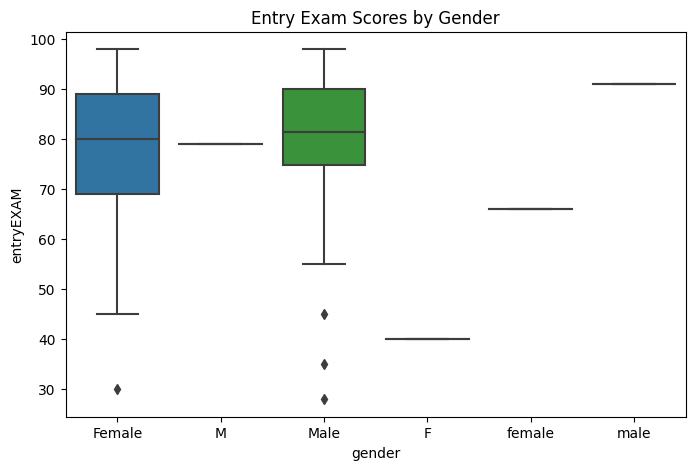

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x="gender", y="entryEXAM", data=df)
plt.title("Entry Exam Scores by Gender")
plt.show()


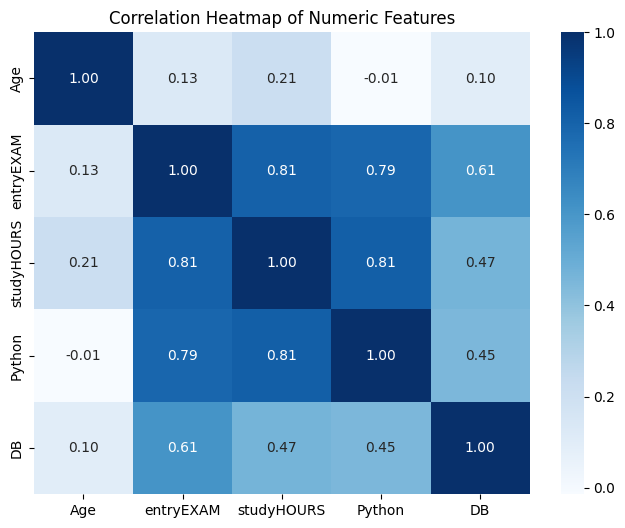

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Age','entryEXAM','studyHOURS','Python','DB']].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

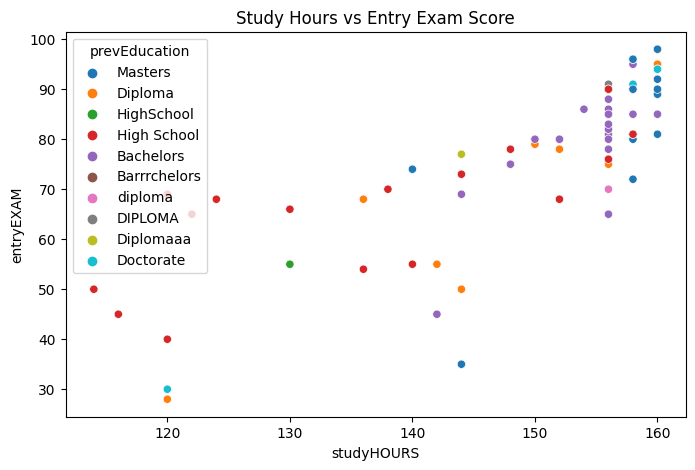

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="studyHOURS", y="entryEXAM", hue="prevEducation", data=df)
plt.title("Study Hours vs Entry Exam Score")
plt.show()

## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# ML Models
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor


In [22]:
# Fill numeric NaN with median
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical NaN with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

label_cols = ['fNAME','lNAME','gender','country','residence','prevEducation']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop("entryEXAM", axis=1)   # Features
y = df["entryEXAM"]                # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVM": SVR(),
    "XGBoost": XGBRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred) * 100
    results[name] = r2
    print(f"{name:20} : {r2:.2f} %")


Linear Regression    : 72.50 %
Random Forest        : 59.95 %
Gradient Boosting    : 46.32 %
SVM                  : 7.47 %
XGBoost              : 35.02 %


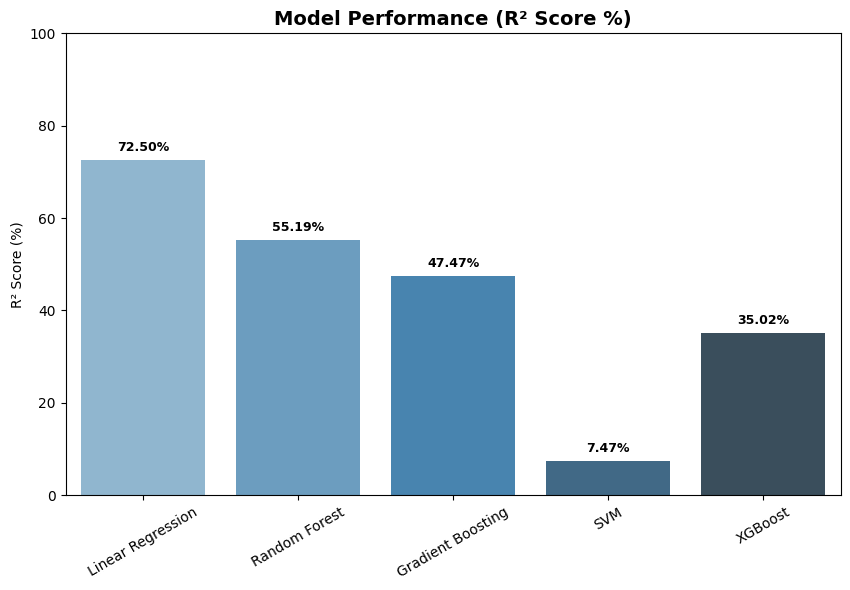

In [24]:
results = {
    "Linear Regression": 72.50,
    "Random Forest": 55.19,
    "Gradient Boosting": 47.47,
    "SVM": 7.47,
    "XGBoost": 35.02
}

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="Blues_d")
plt.title("Model Performance (R² Score %)", fontsize=14, fontweight="bold")
plt.ylabel("R² Score (%)")
plt.ylim(0,100)
plt.xticks(rotation=30)

# Annotate values on top
for i, v in enumerate(results.values()):
    plt.text(i, v + 2, f"{v:.2f}%", ha="center", fontsize=9, fontweight="bold")

plt.show()

## Thank you...pls upvote!!!